In [1]:
# ambiente anaconda
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/Udemy/bin/python


In [2]:
# versão do python
print(sys.version)

3.11.9 (main, Apr 19 2024, 16:48:06) [GCC 11.2.0]


In [3]:
# # caso queira fazer no google drive
# from google.colab import drive
# drive.mount('/content/drive')
import os
# DRIVE_DIRECTORY = "curso_ml"
# DRIVE_DIRECTORY = os.path.join("/content/drive/MyDrive", DRIVE_DIRECTORY)

In [4]:
# importar as bibliotecas
import pickle

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB
from yellowbrick.classifier import ConfusionMatrix

# Aprendizagem bayesiana (Naive Bayes)

Comece recuperando os dados preditores, de treino e de teste, a partir do arquivo `cover_type.pkl` salvo na pasta do Drive. Lembre-se de que você deve instanciar as variáveis `X` e `y`, dos splits `train` e `test`,  na mesma ordem em que salvou.

In [6]:
DRIVE_DIRECTORY_fonte ='../../2-3-Classificacao/Exercicio_Faltante_Classificacao'

In [7]:
with open(os.path.join(DRIVE_DIRECTORY_fonte, "cover_type_exer3.pkl"), "rb") as f:
    (X_train, y_train, X_test, y_test) = pickle.load(f)

Verificar os registros => Use o atributo `shape` para verificar quantas instâncias e quantos atributos têm cada uma dessas variáveis.

In [9]:
# dados do treino 
X_train.shape, y_train.shape

((7500, 53), (7500,))

In [11]:
# teste, como 25% dos dados
X_test.shape, y_test.shape

((2500, 53), (2500,))

Agora, seguindo os exemplos apresentandos na aula, implemente uma instância da classe `GaussianNB`, e logo em seguida use os dados de treino para ajustar este classificador.

In [15]:
# GaussianNB: Classificador baseado em probabilidades e na curva de Gauss.
# fit: O modelo 'estuda' os dados para criar a tabela de probabilidades.

In [12]:
# utilizar o algoritmo GaussianNB
naive_classifier = GaussianNB()
naive_classifier.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [14]:
naive_classifier.get_params()

{'priors': None, 'var_smoothing': 1e-09}

O GaussianNB é um dos algoritmos de classificação mais simples e rápidos da inteligência artificial. O algoritmo faz parte da família Naive Bayes (Bayes "Ingênuo").

1. O que é o GaussianNB?
O "NB" vem de Naive Bayes, que se baseia no Teorema de Bayes para calcular probabilidades. O termo Gaussian (Gaussiano) significa que ele assume que os seus dados numéricos (como as colunas Elevation, Aspect, etc.) seguem uma Distribuição Normal (aquela famosa curva em formato de sino).

Ele calcula a probabilidade de uma linha de dados pertencer a cada classe (ex: qual o tipo de árvore) e escolhe a que tiver a maior probabilidade.

2. O que as linhas do seu código fazem?
naive_classifier = GaussianNB(): Estamos criando o "cérebro" do modelo. Aqui você define que quer usar a lógica de probabilidades gaussianas.

naive_classifier.fit(X_train, y_train): É o treinamento. O modelo olha para os dados de treino (X_train) e para as respostas corretas (y_train) e aprende a "médias" e o "desvio padrão" de cada característica para cada tipo de árvore.

3. Por que ele é chamado de "Ingênuo" (Naive)?
Ele é chamado de ingênuo porque ele assume uma mentira matemática para simplificar as coisas: ele acredita que cada coluna é totalmente independente da outra.

No seu caso, ele ignora se a Elevation tem relação com o Slope. Ele analisa cada uma isoladamente. Mesmo sendo "mentira", ele costuma funcionar surpreendentemente bem para classificações rápidas.

4. Usar como?
Quando tem muitos dados e precisa de um modelo muito rápido.

Como um "ponto de partida" (baseline) para comparar com modelos mais complexos como Redes Neurais ou Random Forest.

Funciona bem com dados que foram padronizados (com aquele StandardScaler!).

1. O "Mapa" de cada classe (Treinamento)Quando você treina o modelo, ele não decora as linhas, ele tira uma "foto" estatística de cada tipo de cobertura florestal (Cover_Type).Para o Tipo 1 (Spruce/Fir), ele calcula a média e o desvio padrão da Elevation.Ele faz o mesmo para o Tipo 2, Tipo 3, e assim por diante.Ele assume que, se você plotar os dados de cada árvore, eles formarão aquela curva de sino (Gaussiana).

2. A Pergunta: "Quem é esse cara?" (Predição)Quando você entrega uma nova linha de dados (sem a resposta), o algoritmo faz o seguinte:Ele olha a Elevation daquela linha.Ele checa em qual das "curvas de sino" que ele desenhou aquele valor se encaixa melhor.Se a Elevation é 3000m, e a média do Tipo 1 é 2900m, a probabilidade de ser Tipo 1 sobe.Ele repete isso para todas as colunas (Slope, Aspect, etc.).

3. A Matemática "Ingênua" (Multiplicação)É aqui que entra o Teorema de Bayes. O modelo multiplica todas as probabilidades que encontrou:$$P(\text{Classe} | \text{Dados}) \propto P(\text{Classe}) \times P(\text{Coluna 1} | \text{Classe}) \times P(\text{Coluna 2} | \text{Classe}) \dots$$P(Classe): É a frequência (quão comum é essa árvore no seu dataset).P(Coluna | Classe): É quão provável é ver aquele valor específico naquela árvore.O "pulo do gato": Ele é chamado de Ingênuo porque ele simplesmente multiplica tudo, ignorando se uma coluna influencia a outra. Para ele, o mundo é feito de características independentes.


5. O VereditoNo final, ele terá uma nota de probabilidade para cada Cover_Type.Tipo 1: 85%Tipo 2: 10%Tipo 3: 5%Ele escolhe o vencedor (85%) e te entrega como resposta.

Exemplo

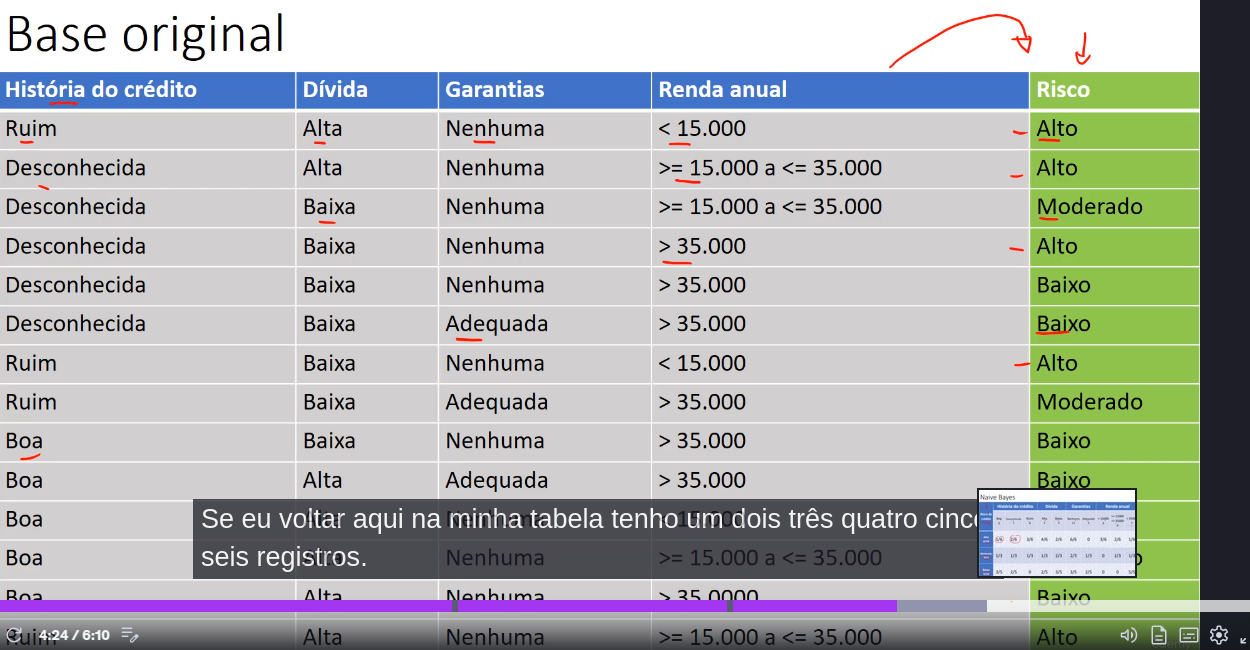

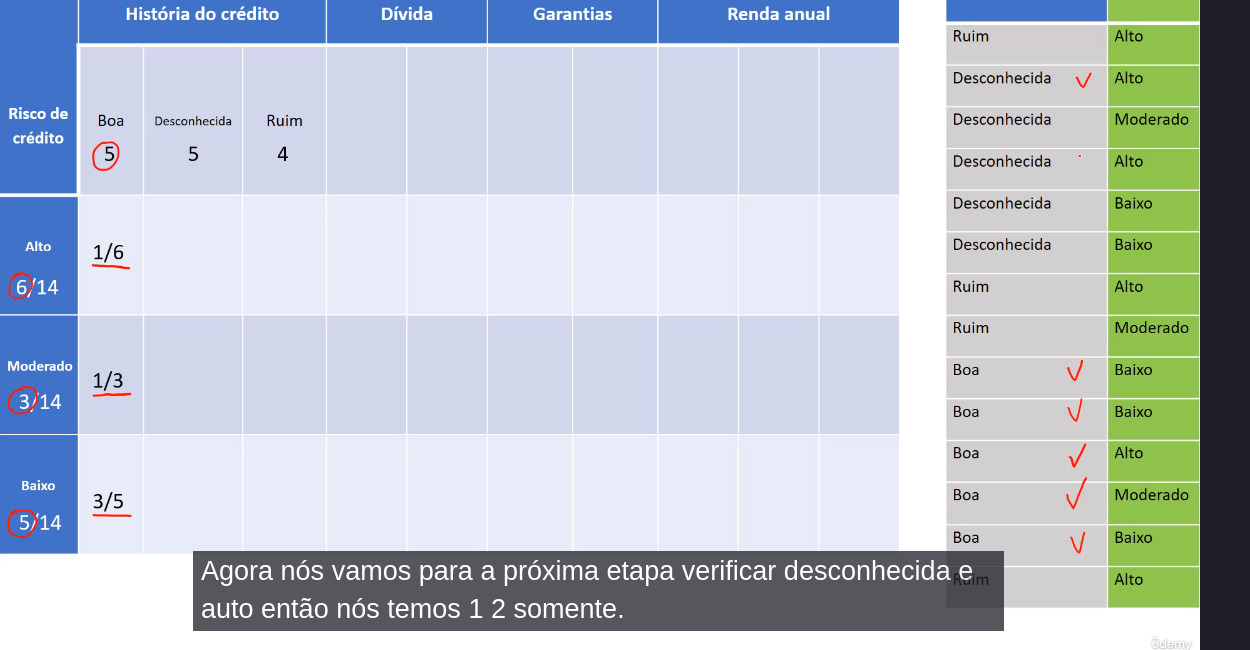

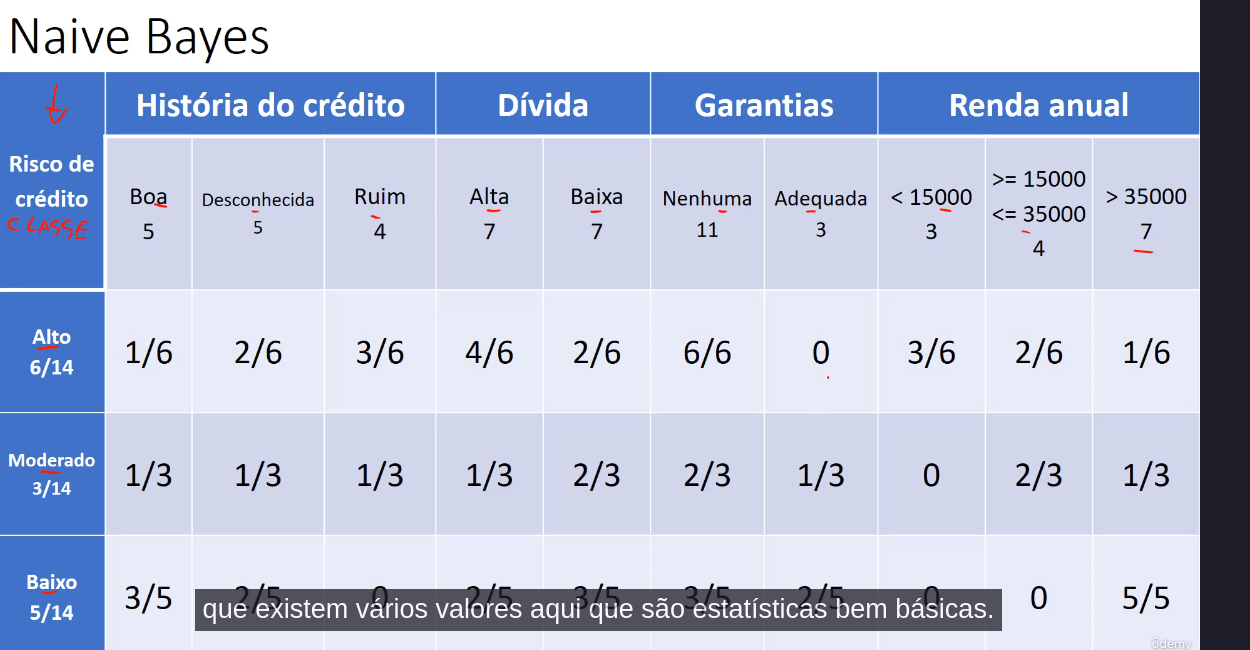

6 valores de alta / 14 dados totais

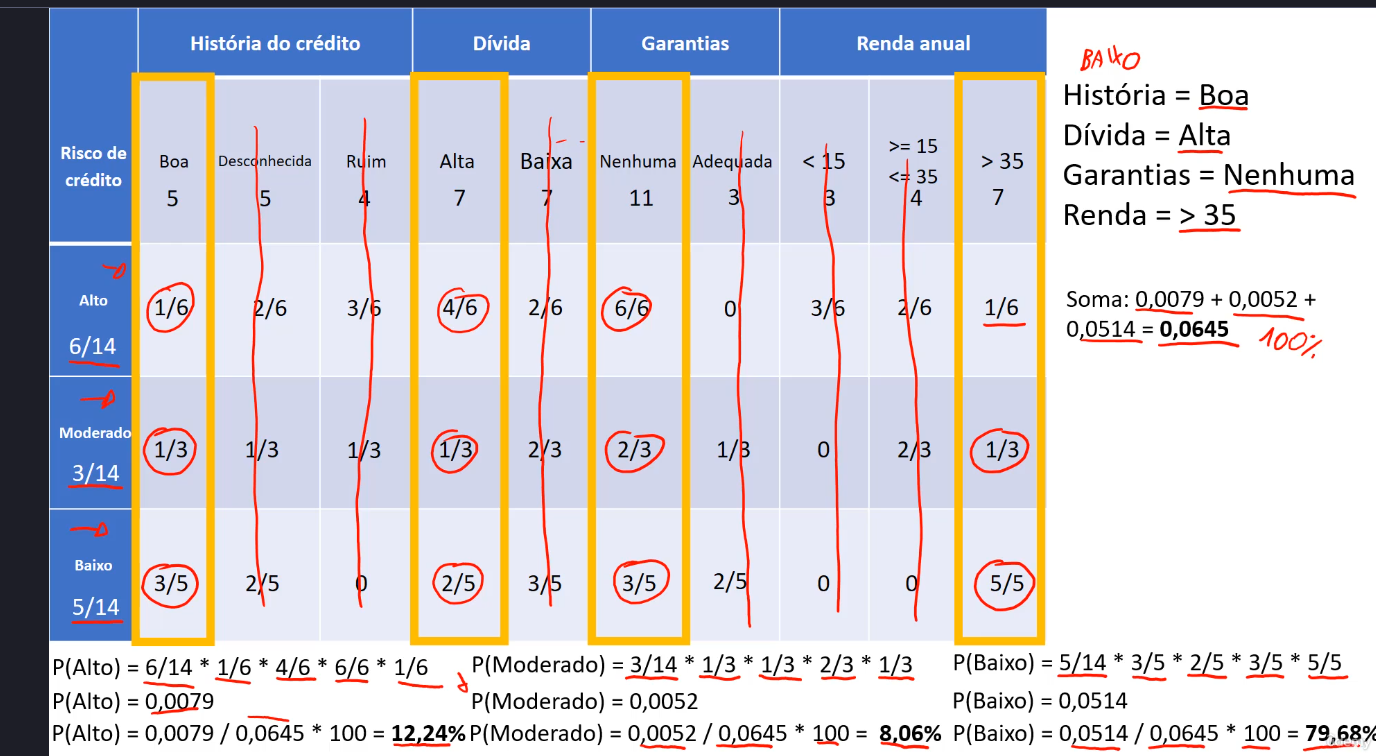

### DICA: observe que instanciar o classificador em um Jupyter Notebook exibe um pequeno card com dois botões no topo: (i) que fornece informações sobre o classificador, e (?) que o leva para a documentação.

### Use o classificador ajustado para fazer predições com os dados de teste.

## classificador treinado para fazer a previsão

In [16]:
y_pred = naive_classifier.predict(X_test)

In [17]:
# chamando o naive_classifier que foi passado pelo algoritmo e classificado
# e prever com o predict no X_test, dados previsores

Exiba esses resultados.

In [20]:
y_pred # previsão

array([0, 3, 1, ..., 3, 3, 1], shape=(2500,))

In [18]:
y_test # valor real de teste

array([4, 4, 1, ..., 6, 6, 5], shape=(2500,))

Utilize a função adequada para determinar a acurácia deste classificador no split de teste.

In [21]:
accuracy_score(y_test, y_pred)

0.142

In [22]:
print(f'tivemos apenas {accuracy_score(y_test, y_pred)*100} % de acurácia ou acerto')

tivemos apenas 14.2 % de acurácia ou acerto


Exiba a matriz de confusão para o classificador.

0.142

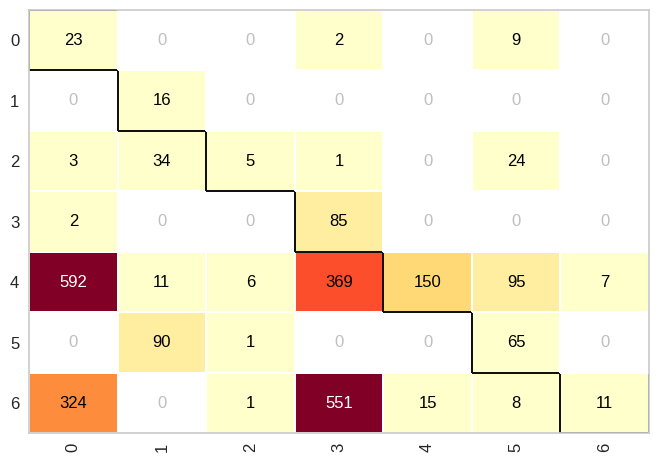

In [23]:
# na \ reta de descida é o acerto, nas bordas os erros dos acertos
cm = ConfusionMatrix(naive_classifier)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

apa de "Alvos vs. Tiros".

O objetivo é entender não apenas o quanto o modelo acerta, mas exatamente onde ele está se confundindo.

1. Os dois eixos principais
#### Eixo Vertical (True Class): É a realidade. O que a árvore realmente é no mundo real.

#### Eixo Horizontal (Predicted Class): É o palpite do modelo. O que o GaussianNB achou que era.

2. A "Diagonal da Vitória"
O ponto mais importante do gráfico é a diagonal que desce da esquerda para a direita.

Os quadrados que ficam nessa linha representam os acertos.

Quanto mais escura (ou intensa) for a cor nesses quadrados, melhor o seu modelo está para aquela classe específica.

## Exiba o reporte de classificação no split de teste.

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.02      0.68      0.05        34
           1       0.11      1.00      0.19        16
           2       0.38      0.07      0.12        67
           3       0.08      0.98      0.16        87
           4       0.91      0.12      0.22      1230
           5       0.32      0.42      0.36       156
           6       0.61      0.01      0.02       910

    accuracy                           0.14      2500
   macro avg       0.35      0.47      0.16      2500
weighted avg       0.70      0.14      0.15      2500



Estes resultados ficaram bem insatisfatórios. A acurácia não chegou a 15%, mas curiosamente nós observamos no reporte acima que a precisão foi alta para a classe 4, enquanto que o recall foi máximo para a classe 1. Entretanto, o score f1 ficou baixo para todas as classes.

In [36]:
# alta precisão apenas no número 4. Precisão alta e baixo recall => o modelo preve valores mais certos
# no 0,1,3 os valores do recall são altos e a precisão baixa => modelo identifica muitos valores de falsos positivos

In [39]:
# *****  boa previsão quando a precision é alta e o recall baixo, porém detecta poucos valores reais *****

In [33]:
# classes 2,5 e 6
# desempenho misto e o resultado ruim, boa precisão, mas quase não detecta valores reais (quando o recall é baixo)
# precision valor de 0,61 na classe 6, e baixo recall, de 0,01, sem valores reais, mas boa precisão



In [34]:
# Precision: Qualidade (não mentir).
# Recall: Quantidade (não esquecer ninguém).
# F1-Score: O meio-termo ideal.
# Support: Quantos dados reais foram testados.

Essas quatro métricas são o "boletim escolar" do seu modelo. Elas dizem não apenas quanto ele acertou, mas como ele errou.

Imagine que o modelo está tentando identificar árvores do tipo "Aspen":

1. Precision (Precisão)
Pergunta: "De todas as vezes que o modelo disse que era Aspen, quantas eram realmente Aspen?"

Foco: Evitar alarmes falsos.

Se a precisão é 0.80, significa que quando o modelo aponta para uma árvore e diz "É Aspen", ele acerta 80% das vezes.

2. Recall (Revocação / Sensibilidade)
Pergunta: "De todas as árvores Aspen que existem de verdade no mato, quantas o modelo conseguiu encontrar?"

Foco: Não deixar passar nada.

Se o recall é 0.60, significa que o modelo só achou 60% das Aspens totais; as outras 40% ele confundiu com outro tipo.

3. F1-Score
O que é: Uma média (harmônica) entre a Precisão e o Recall.

Foco: Equilíbrio.

É a melhor métrica para olhar se você quer um resumo rápido, pois se a Precisão for ótima mas o Recall for péssimo (ou vice-versa), o F1-Score cai.

4. Support (Suporte)
O que é: A quantidade real de exemplos daquela classe no seu conjunto de testes.

Foco: Contexto.

Se o suporte de uma árvore é 10 e de outra é 5000, você sabe que o resultado da primeira não é tão confiável estatisticamente quanto o da segunda.

---

In [44]:
from sklearn.preprocessing import LabelEncoder

# # 1. Recriamos o objeto
# label_encoder = LabelEncoder()

# # 2. "Ensinamos" a ele os nomes novamente usando a coluna original do DataFrame
# # Isso restaura a memória do encoder (o mapeamento de nomes para números)
# label_encoder.fit(base['Cover_Type'])

# # 3. Agora o comando vai funcionar!
# y_pred_strings = label_encoder.inverse_transform(y_pred)
# y_test_strings = label_encoder.inverse_transform(y_test)

# print("Nomes traduzidos com sucesso!")
# print(label_encoder.classes_)

In [47]:
# # 1. Primeiro, geramos as previsões (que virão como números: 0, 1, 2...)
# y_pred = naive_classifier.predict(X_test)

# # 2. Agora, traduzimos os números de volta para os nomes das árvores
# y_pred_strings = label_encoder.inverse_transform(y_pred)

# # 3. Fazemos o mesmo para o y_test para podermos comparar "Nome vs Nome"
# y_test_strings = label_encoder.inverse_transform(y_test)

# # 4. Criamos uma tabela para você ver os 10 primeiros resultados reais
# import pandas as pd
# df_resultados = pd.DataFrame({
#     'Classe Real': y_test_strings,
#     'Previsão do Modelo': y_pred_strings
# })

# print("--- Primeiros 10 resultados traduzidos ---")
# print(df_resultados.head(10))

In [41]:
# # 1. Converte o array de números (y_pred) para os nomes originais (strings)
# y_pred_nomes = label_encoder.inverse_transform(y_pred)

# # 2. Se quiser ver os nomes reais do conjunto de teste para comparar
# y_test_nomes = label_encoder.inverse_transform(y_test)

# # 3. Vamos ver os 10 primeiros resultados lado a lado
# import pandas as pd
# comparacao = pd.DataFrame({
#     'Real': y_test_nomes,
#     'Previsão': y_pred_nomes
# })

# print(comparacao.head(10))

# no arquivo original => M3_Exercicio_classificacao_pre_processamento_dos_dados.ipynb


In [46]:
# no arquivo original => M3_Exercicio_classificacao_pre_processamento_dos_dados.ipynb
# y = base.iloc[:, -1].values
# base.columns[-1] # a coluna de interesse, o target, ou seja a classe é esta
# 'Cover_Type'

# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(y)
# # Mostra a lista de nomes na ordem (0, 1, 2...)
# print(label_encoder.classes_)
# {0: 'Aspen', 1: 'Cottonwood/Willow', 2: 'Douglas-fir', 3: 'Krummholz', 4: 'Lodgepole Pine', 5: 'Ponderosa Pine', 6: 'Spruce/Fir'}


In [49]:
import pandas as pd

# O seu dicionário de mapeamento
mapa_nomes = {0: 'Aspen', 1: 'Cottonwood/Willow', 2: 'Douglas-fir', 
              3: 'Krummholz', 4: 'Lodgepole Pine', 5: 'Ponderosa Pine', 
              6: 'Spruce/Fir'}

# Criando o DataFrame de comparação
df_comparacao = pd.DataFrame({
    'Real': y_test,
    'Previsão': y_pred
})

# Traduzindo as colunas usando o dicionário
df_comparacao['Real_Nome'] = df_comparacao['Real'].map(mapa_nomes)
df_comparacao['Previsao_Nome'] = df_comparacao['Previsão'].map(mapa_nomes)

display(df_comparacao[['Real_Nome', 'Previsao_Nome']].head(10))

,Real_Nome,Previsao_Nome
0,Lodgepole Pine,Aspen
1,Lodgepole Pine,Krummholz
2,Cottonwood/Willow,Cottonwood/Willow
3,Lodgepole Pine,Aspen
4,Lodgepole Pine,Krummholz
5,Spruce/Fir,Krummholz
6,Lodgepole Pine,Krummholz
7,Spruce/Fir,Krummholz
8,Lodgepole Pine,Aspen
9,Lodgepole Pine,Aspen


**EXTRA**

De acordo com a [documentação da classe GaussianNB](https://scikit-learn.org/stable/modules/naive_bayes.html#gaussian-naive-bayes):

> "A probabilidade dos atributos é assumida como gaussiana". <br>
<b>Gaussiana => Tipo de distribuição estatística

Entretanto, nós não temos qualquer razão preliminar para assumir esta premissa. Se ela não for verdadeira, isso pode explicar a baixa acurácia do modelo.

Na mesma página do link, você vai encontrar outros classificadores bayesianos com implementação na biblioteca. Veja que a classe `BernoulliNB` faz uma suposição diferente: ela assume que os atributos seguem uma distribuição de Bernoulli. Tente utilizar esta classe para verificar se obtém resultados melhores.

---

Bernoulli

In [51]:
from sklearn.naive_bayes import BernoulliNB

In [52]:
naive_classifier = BernoulliNB()
naive_classifier.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [53]:
naive_classifier.get_params()

{'alpha': 1.0,
 'binarize': 0.0,
 'class_prior': None,
 'fit_prior': True,
 'force_alpha': True}

In [54]:
y_pred = naive_classifier.predict(X_test)

In [55]:
y_pred

array([4, 4, 1, ..., 6, 6, 2], shape=(2500,))

In [56]:
accuracy_score(y_test, y_pred)

0.642

In [57]:
print(f'tivemos {accuracy_score(y_test, y_pred)*100} % de acurácia ou acerto no método Bernoulli')

tivemos 64.2 % de acurácia ou acerto no método Bernoulli


In [58]:
# resultado melhor, acima dos 50%

0.642

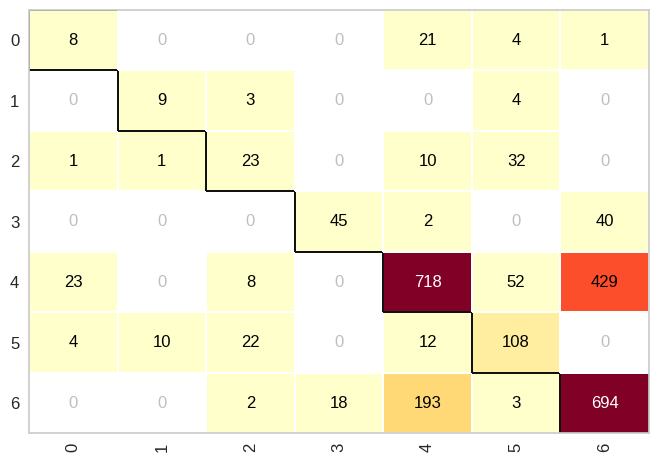

In [59]:
cm = ConfusionMatrix(naive_classifier)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.22      0.24      0.23        34
           1       0.45      0.56      0.50        16
           2       0.40      0.34      0.37        67
           3       0.71      0.52      0.60        87
           4       0.75      0.58      0.66      1230
           5       0.53      0.69      0.60       156
           6       0.60      0.76      0.67       910

    accuracy                           0.64      2500
   macro avg       0.52      0.53      0.52      2500
weighted avg       0.66      0.64      0.64      2500



In [61]:
# apenas a classe 0 teve um valor ruim, de 0,22 de precisão e recall de 0,24

### De fato os resultados ficaram consideravelmente melhores, o que é um indicativo de que os atributos (pelo menos na forma transformada apresentada ao algoritmo, com escalonamento e *one hot encoding*) seguem uma distribuição mais bernoulliana do que gaussiana.